# Read LiveOcean Layers Icechunk Store

Opens the virtual Icechunk store created by `layers_icechunk.ipynb` in xarray.

In [1]:
import os
import icechunk
import xarray as xr

In [2]:
os.environ['AWS_REQUEST_CHECKSUM_CALCULATION'] = 'when_required'
os.environ['AWS_RESPONSE_CHECKSUM_VALIDATION'] = 'when_required'

In [3]:
storage_endpoint = "https://s3.kopah.uw.edu"
storage_bucket   = "liveocean-share"
storage_name     = "icechunk-test-1"
bucket_url       = f"s3://{storage_bucket}"

In [4]:
storage = icechunk.s3_storage(
    bucket=storage_bucket,
    prefix=f"icechunk/{storage_name}",
    from_env=True,
    endpoint_url=storage_endpoint,
    region='not-used',
    force_path_style=True,
)

config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=f"{bucket_url}/",
        store=icechunk.s3_store(
            region="not-used",
            anonymous=False,
            s3_compatible=True,
            force_path_style=True,
            endpoint_url=storage_endpoint,
        ),
    )
)

credentials = icechunk.containers_credentials(
    {f"{bucket_url}/": icechunk.s3_credentials(anonymous=False)}
)

repo = icechunk.Repository.open(
    storage, config, authorize_virtual_chunk_access=credentials
)
session = repo.readonly_session("main")
print(repo)

<icechunk.Repository (v2)>
storage:
    <icechunk.Storage>
    type: S3 (native)
    bucket: liveocean-share
    prefix: icechunk/icechunk-test-1
    region: not-used
    endpoint_url: https://s3.kopah.uw.edu
    force_path_style: True
config: <RepositoryConfig ...>



In [5]:
ds = xr.open_zarr(session.store, consolidated=False, chunks={})
ds

<xarray.Dataset> Size: 5GB
Dimensions:                (ocean_time: 18, eta_rho: 1302, xi_rho: 663)
Coordinates:
  * ocean_time             (ocean_time) datetime64[ns] 144B 2025-07-15 ... 20...
Dimensions without coordinates: eta_rho, xi_rho
Data variables: (12/46)
    ARAG_20                (ocean_time, eta_rho, xi_rho) float64 124MB dask.array<chunksize=(1, 1302, 663), meta=np.ndarray>
    NO3_30                 (ocean_time, eta_rho, xi_rho) float64 124MB dask.array<chunksize=(1, 1302, 663), meta=np.ndarray>
    NO3_20                 (ocean_time, eta_rho, xi_rho) float64 124MB dask.array<chunksize=(1, 1302, 663), meta=np.ndarray>
    ARAG_30                (ocean_time, eta_rho, xi_rho) float64 124MB dask.array<chunksize=(1, 1302, 663), meta=np.ndarray>
    ARAG_50                (ocean_time, eta_rho, xi_rho) float64 124MB dask.array<chunksize=(1, 1302, 663), meta=np.ndarray>
    NO3_10                 (ocean_time, eta_rho, xi_rho) float64 124MB dask.array<chunksize=(1, 1302, 663), meta=np.ndarray>
    ...                     ...
    temp_20                (ocean_time, eta_rho, xi_rho) float64 124MB dask.array<chunksize=(1, 1302, 663), meta=np.ndarray>
    salt_bottom            (ocean_time, eta_rho, xi_rho) float32 62MB dask.array<chunksize=(1, 1302, 663), meta=np.ndarray>
    salt_20                (ocean_time, eta_rho, xi_rho) float64 124MB dask.array<chunksize=(1, 1302, 663), meta=np.ndarray>
    temp_50                (ocean_time, eta_rho, xi_rho) float64 124MB dask.array<chunksize=(1, 1302, 663), meta=np.ndarray>
    temp_surface           (ocean_time, eta_rho, xi_rho) float32 62MB dask.array<chunksize=(1, 1302, 663), meta=np.ndarray>
    temp_bottom            (ocean_time, eta_rho, xi_rho) float32 62MB dask.array<chunksize=(1, 1302, 663), meta=np.ndarray>
Attributes:
    history:                Tue Jul 15 14:38:56 2025: ncrcat -p /dat1/parker/...
    NCO:                    netCDF Operators version 5.2.7 (Homepage = http:/...
    nco_input_file_number:  19
    nco_input_file_list:    layers_000000.nc layers_000001.nc layers_000002.n...

In [6]:
ds.ocean_time.values

array(['2025-07-15T00:00:00.000000000', '2025-07-15T04:00:00.000000000',
       '2025-07-15T08:00:00.000000000', '2025-07-15T12:00:00.000000000',
       '2025-07-15T16:00:00.000000000', '2025-07-15T20:00:00.000000000',
       '2025-07-16T00:00:00.000000000', '2025-07-16T04:00:00.000000000',
       '2025-07-16T08:00:00.000000000', '2025-07-16T12:00:00.000000000',
       '2025-07-16T16:00:00.000000000', '2025-07-16T20:00:00.000000000',
       '2025-07-17T00:00:00.000000000', '2025-07-17T04:00:00.000000000',
       '2025-07-17T08:00:00.000000000', '2025-07-17T12:00:00.000000000',
       '2025-07-17T16:00:00.000000000', '2025-07-17T20:00:00.000000000'],
      dtype='datetime64[ns]')

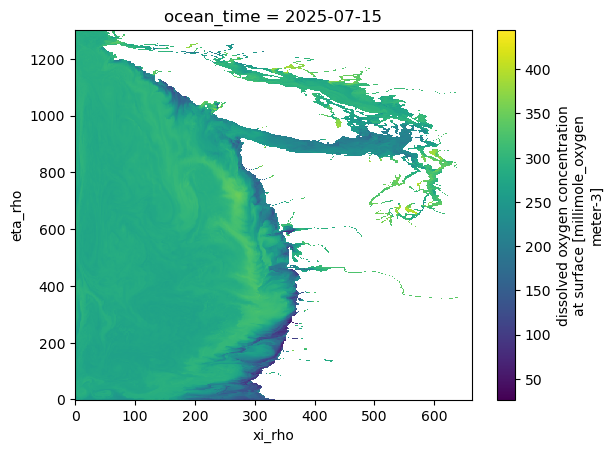

In [9]:
ds.oxygen_surface.isel(ocean_time=0).plot()